In [ ]:
            #-------Normalization-------#
# Normalization is a type of feature scaling where values are transformed into a specific range, usually [0, 1].

# When to use?
# We use normalization (feature scaling) when numerical features have different scales
# Model’s performance depends on distance, magnitude, or gradient.

In [ ]:
# Type of Normalization:
    # 1. MinMax Scaling
    # 2. Mean Normalization
    # 3. MaxAbsolute Scaling
    # 4. Robust Scaling

In [ ]:
# MinMax Scaling 
    # Formula: Xnorm=Xi-Xmin/Xmax-Xmin
    # After Scaling Data distribution will be [0 to 1]
# When to use
    # Data has no extreme outliers
    # You need values between 0 and 1
    # Algorithms using distance or gradients
    # It is sensitive to outlier

In [1]:
# Example code of MinMax Scalng

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Import Wine Dataset
Df=pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2])
Df.columns=['Class label', 'Alcohol', 'Malic acid']
Df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

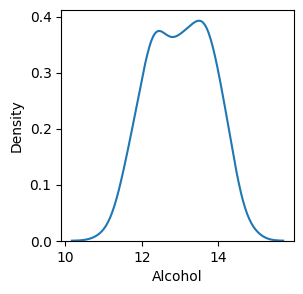

In [7]:
# Show the distribution of alcohol column
plt.figure(figsize=(3,3))
sns.kdeplot(data=Df, x='Alcohol')

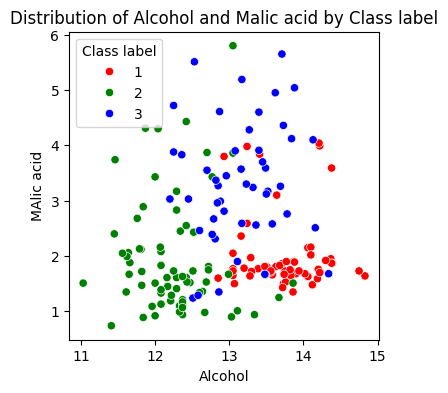

In [9]:
# Draw scatterplot
plt.figure(figsize=(4,4))
sns.scatterplot(
    data=Df,
    x='Alcohol', 
    y='Malic acid', 
    hue='Class label', 
    palette=['red', 'green', 'blue'])
plt.title('Distribution of Alcohol and Malic acid by Class label')
plt.xlabel('Alcohol')
plt.ylabel('MAlic acid')
plt.show()

In [ ]:
# perform scaling to bring the numerical value into same range

# Before scaling split the dataset into train and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    Df.drop( 'Class label', axis=1),
    Df['Class label'],
    test_size=0.3,
    random_state=0
)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [19]:
# Now perform scaling
from sklearn.preprocessing import MinMaxScaler
# Create object
scaler=MinMaxScaler()

In [20]:
# Fit the scaler object to train set
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [21]:
# Tranform the X_train and X_test dataset
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [22]:
# Convert numpy array to dataframe
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

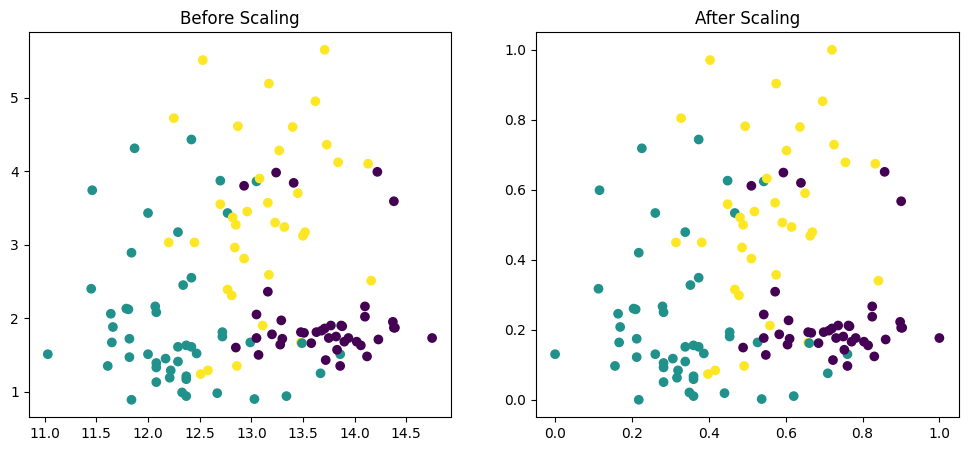

In [24]:
# Draw Scatter plot after scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

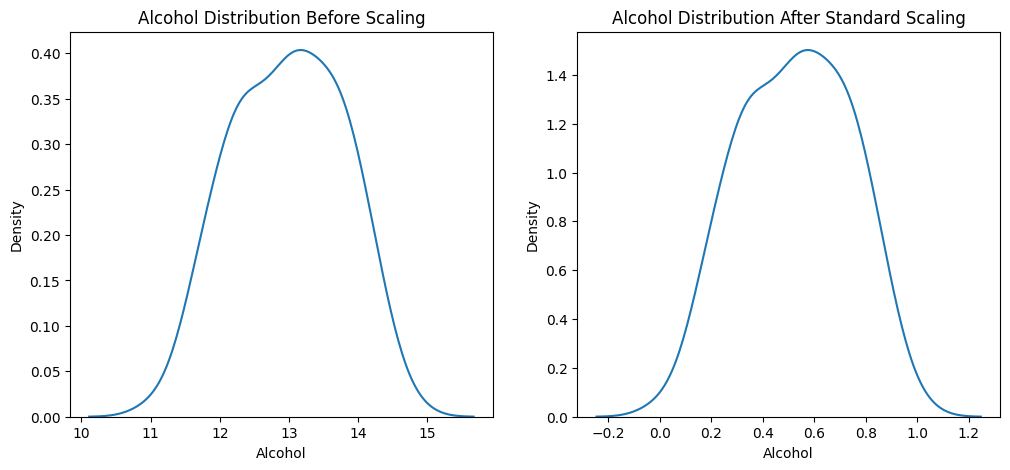

In [25]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

In [ ]:
# The shape of distribution in both (after scaling and before scaling) is equal.

In [26]:
# Import liraries
from sklearn.linear_model import LogisticRegression

# Create object
lr=LogisticRegression()
lr_scaled=LogisticRegression()

# Fit X_train and X_train_scaled
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
# Make prediction
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [28]:
# Show the model accuracy
from sklearn.metrics import accuracy_score
print('Actual:', accuracy_score( y_test, y_pred))
print('Scaled:', accuracy_score( y_test, y_pred_scaled))

Actual: 0.7592592592592593
Scaled: 0.7962962962962963


In [ ]:
# Improve the accuracy after scaling

In [ ]:
# Robust Scaling
    # Uses median and IQR (Interquartile Range) instead of mean and std.
    # Formula, Xrobust=Xi-median/IQR
    # Robust to outlier
    # RobustScaller of sklearn

# When to use:
    # Dataset has many outliers
# Used in:
    # Regression models
    # Distance-based models with outliers

In [ ]:
# Max Abs Scaling
    # Divides values by the maximum absolute value.
    # Formula: Xmaxabs=X/|X|
    # Range[-1,1]
# Useful for
    # sparse Data
    # Text data
    # High-Dimentional sparse data
